In [1]:
import streamlit as st
import joblib
import pandas as pd

##Load the trained model and TF-IDF vectorizer

In [2]:
model = joblib.load("models/random_forest_model.pkl")

tfidf = joblib.load("models/tfidf_vectorizer.pkl")

print("Model loaded successfully!")
print("TF-IDF vectorizer loaded successfully!")

Model loaded successfully!
TF-IDF vectorizer loaded successfully!


In [3]:
print(model)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [4]:
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

Number of TF-IDF features: 5000


In [5]:
sample_news = """
Scientists announced a new study examining climate change and
its effects on global temperatures.
"""

In [6]:
sample_tfidf = tfidf.transform([sample_news])

print("TF-IDF shape:", sample_tfidf.shape)

TF-IDF shape: (1, 5000)


In [7]:
prediction = model.predict(sample_tfidf)[0]

print("Prediction:", prediction)

Prediction: 0


In [8]:
probabilities = model.predict_proba(sample_tfidf)[0]

print("Probabilities:", probabilities)

Probabilities: [0.985 0.015]


In [9]:
real_probability = probabilities[0] * 100
fake_probability = probabilities[1] * 100

print("Real News Probability:", real_probability, "%")
print("Fake News Probability:", fake_probability, "%")

Real News Probability: 98.5 %
Fake News Probability: 1.5 %


In [10]:
if prediction == 1:
    print("🚨 FAKE NEWS DETECTED")
else:
    print("✅ REAL NEWS DETECTED")

✅ REAL NEWS DETECTED


In [11]:
confidence = max(probabilities) * 100

print("Model Confidence:", confidence, "%")

Model Confidence: 98.5 %


In [12]:
feature_names = tfidf.get_feature_names_out()

print("Total features:", len(feature_names))

Total features: 5000


In [13]:
input_features = sample_tfidf.toarray()[0]

print(input_features)

[0. 0. 0. ... 0. 0. 0.]


In [15]:
input_features = sample_tfidf.toarray()[0]

print(input_features)

[0. 0. 0. ... 0. 0. 0.]


In [16]:
non_zero_indices = input_features.nonzero()[0]

print("Number of words/features found:", len(non_zero_indices))

Number of words/features found: 8


In [17]:
words_present = feature_names[non_zero_indices]

print(words_present)

['announced' 'change' 'climate' 'effects' 'global' 'new' 'scientists'
 'study']


In [18]:
feature_importance = model.feature_importances_

print("Number of feature importance values:", len(feature_importance))

Number of feature importance values: 5000


In [19]:
explanation_data = []

for index in non_zero_indices:
    
    word = feature_names[index]
    
    importance = feature_importance[index]
    
    tfidf_score = input_features[index]
    
    influence = importance * tfidf_score
    
    explanation_data.append({
        "Word": word,
        "Feature Importance": importance,
        "TF-IDF Score": tfidf_score,
        "Influence": influence
    })

print("Explanation data created successfully!")

Explanation data created successfully!


In [20]:
explanation_df = pd.DataFrame(explanation_data)

explanation_df

,Word,Feature Importance,TF-IDF Score,Influence
0,announced,0.000017,0.290485,0.000005
1,change,0.000014,0.265985,0.000004
2,climate,0.000140,0.364149,0.000051
3,effects,0.000014,0.451347,0.000006
4,global,0.000021,0.316456,0.000007
5,new,0.000021,0.162716,0.000003
6,scientists,0.000039,0.474082,0.000019
7,study,0.000027,0.396457,0.000011


In [21]:
explanation_df = explanation_df.sort_values(
    by="Influence",
    ascending=False
)

explanation_df

,Word,Feature Importance,TF-IDF Score,Influence
2,climate,0.000140,0.364149,0.000051
6,scientists,0.000039,0.474082,0.000019
7,study,0.000027,0.396457,0.000011
4,global,0.000021,0.316456,0.000007
3,effects,0.000014,0.451347,0.000006
0,announced,0.000017,0.290485,0.000005
1,change,0.000014,0.265985,0.000004
5,new,0.000021,0.162716,0.000003


In [22]:
top_features = explanation_df.head(10)

top_features

,Word,Feature Importance,TF-IDF Score,Influence
2,climate,0.000140,0.364149,0.000051
6,scientists,0.000039,0.474082,0.000019
7,study,0.000027,0.396457,0.000011
4,global,0.000021,0.316456,0.000007
3,effects,0.000014,0.451347,0.000006
0,announced,0.000017,0.290485,0.000005
1,change,0.000014,0.265985,0.000004
5,new,0.000021,0.162716,0.000003


In [25]:
import matplotlib.pyplot as plt

# Select top features
top_features = explanation_df.head(10)

# Create the chart
plt.figure(figsize=(10, 6))

plt.bar(
    top_features["Word"],
    top_features["Influence"]
)

plt.xlabel("Words")
plt.ylabel("Influence Score")
plt.title("Top Influential Words in News Prediction")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("feature_influence.png")

print("Chart created successfully!")

Chart created successfully!


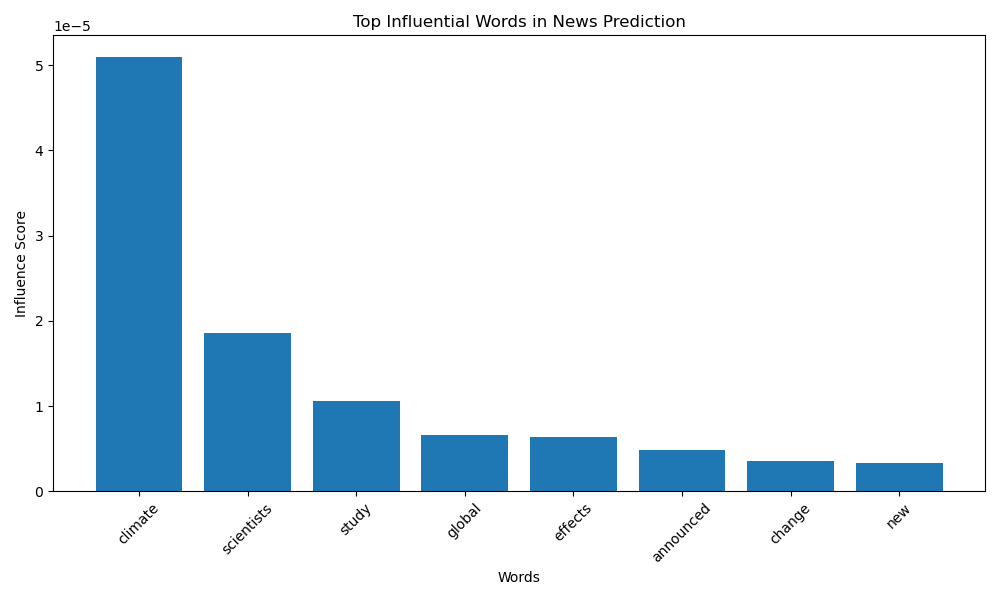

In [26]:
from PIL import Image

img = Image.open("feature_influence.png")

display(img)

In [27]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles and folders:")
print(os.listdir())

Current folder:
d:\Explainable-AI-News-Intelligence-System

Files and folders:
['app', 'app.ipynb', 'app.py', 'data', 'feature_influence.png', 'models', 'notebooks', 'outputs', 'src']


In [28]:
top_5_features = explanation_df.head(5)

print("TOP 5 MOST INFLUENTIAL WORDS")
print("=" * 40)

for i, row in top_5_features.iterrows():
    print(
        f"{row['Word']} → Influence Score: {row['Influence']:.8f}"
    )

TOP 5 MOST INFLUENTIAL WORDS
climate → Influence Score: 0.00005093
scientists → Influence Score: 0.00001855
study → Influence Score: 0.00001054
global → Influence Score: 0.00000656
effects → Influence Score: 0.00000632


In [29]:
fake_news = """
Scientists have officially confirmed that drinking five cups of coffee every
hour can make humans completely immune to all diseases. The discovery was
announced today and experts say hospitals will no longer be needed.
"""

print(fake_news)


Scientists have officially confirmed that drinking five cups of coffee every
hour can make humans completely immune to all diseases. The discovery was
announced today and experts say hospitals will no longer be needed.



In [30]:
fake_tfidf = tfidf.transform([fake_news])

print("TF-IDF Shape:", fake_tfidf.shape)

TF-IDF Shape: (1, 5000)


In [31]:
fake_prediction = model.predict(fake_tfidf)[0]

print("Prediction:", fake_prediction)

Prediction: 0


In [32]:
print(model.classes_)

[0 1]
